<a href="https://colab.research.google.com/github/SLucy0/Data_Analytics/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounting Google Drive-

Connect to Google Drive and find the files.
Connects your Google Colab notebook to my Google Drive.
Looks inside my Drive to confirm access.
Sets a folder path (capstone_project) where your my data files live.
Gets a sorted list of all files in that folder (default, ascending order).

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Confirming access
import os
os.listdir('/content/drive/MyDrive')

Bring in Panda analysis library.

In [ ]:
import pandas as pd

Setting base path

In [ ]:
base_path = "/content/drive/MyDrive/capstone_project"

Loading files-
Creates an empty list (dfs) to store data from each file.
List files in Directory.

In [ ]:
import os

files = sorted(os.listdir(base_path))

Discovered that a select group of files were structured in ways that I could not identify. Used the output after running and rerunning 108 files to create current code.

In [ ]:
dfs = []

#The internal structure of SIFMonthlyRidership_2019_12.xlsx suggests
  #that it might have metadata, empty rows, or a very specific header format that the
  #general approach isn't capturing. SIFMonthlyRidership_2019_12.xlsx is being skipped for now,
  #preventing it from corrupting the rest of the combined data.
file_header_map = {
    'SIFMonthlyRidership_2019_12.xlsx': 0,
    'SIFMonthlyRidership_2020_02 .xlsx': 2,
    'SIFMonthlyRidership_2020_03 .xlsx': 2,
    'SIFMonthlyRidership_2020_04.xlsx': 2,
    'SIFMonthlyRidership_2020_05.xlsx': 3,
    'SIFMonthlyRidership_2020_06.xlsx': 3,
    'SIFMonthlyRidership_2020_07.xlsx': 3,
    'SIFMonthlyRidership_2020_09.xlsx': 2,
    'SIFMonthlyRidership_2020_10.xlsx': 2,
    'SIFMonthlyRidership_2020_11.xlsx': 2,
    'SIFMonthlyRidership_2020_12.xlsx': 3
}

Cleaning the data and normalizing the data.
Loops- Read each file. Default header is 0-indexed. Line 5 is index 4.

Defined a special map (file_header_map) for files that have weird formatting.

Check worksheet names. Open each file differently depending on whether it’s a CSV or an Excel file.  In Excel files, look at all available sheet names. Find the right sheet (‘TOTALS’ or ‘TOTAL’).

In [ ]:
# Open the files
for file in files:
    df = None
    file_path = f"{base_path}/{file}"

    # Default header row (Excel row 5 → index 4)
    current_header_row_index = 4

    # Override header row if file is in the map
    if file in file_header_map:
        current_header_row_index = file_header_map[file]

    # Load file
    if file.endswith('.csv'):
        df = pd.read_csv(file_path, header=current_header_row_index)

    elif file.endswith(('.xls', '.xlsx')):
        try:
            # Try exact "TOTALS"
            df = pd.read_excel(file_path, sheet_name='TOTALS', header=current_header_row_index)

      #If that fails, look at all available sheet names
        except ValueError:
            try:
                xls = pd.ExcelFile(file_path)
                available_sheets = xls.sheet_names

                found_sheet_name = None

                # Look for "TOTALS" (case-insensitive)
                for sheet in available_sheets:
                    if sheet.strip().upper() == 'TOTALS':
                        found_sheet_name = sheet
                        break

                # If not found, look for "TOTAL"
                if found_sheet_name is None:
                    for sheet in available_sheets:
                        if sheet.strip().upper() == 'TOTAL':
                            found_sheet_name = sheet
                            break

                # If found, load it
                if found_sheet_name:
                    df = pd.read_excel(file_path, sheet_name=found_sheet_name, header=current_header_row_index)
                #Skip this file and move on to the next one
                #print a message explaining why file is skipped and list the sheets it does have
                else:
                    print(f"Skipping {file} (no 'TOTALS' or 'TOTAL' sheet found). Available sheets: {available_sheets}")
                    continue

            except Exception as e:
                print(f"Error checking sheets for {file}: {e}")
                print(f"Skipping {file} due to sheet error.")
                continue

        except Exception as e:
            print(f"Error reading Excel file {file}: {e}")
            continue

    # Using Panda, create new column and fill it with the value stored in old file.
    if df is not None:
        df['source_file'] = file

        # Normalize column names
        df.columns = [str(col).strip().upper() for col in df.columns]

        column_rename_map = {
            'DAY': 'Day',
            'DATE': 'Date',
            'WHT': 'WHT',
            'STG': 'STG',
            'COMBINED TOTAL': 'Combined',
            'COMBINED': 'Combined',
            'COMBINED TOTAL.1': 'Combined',
            'DIFFERENCE': 'Difference',
            'DIFF': 'Difference',
            'SOURCE_FILE': 'source_file'
        }

        df.rename(columns=column_rename_map, inplace=True)

        # Debug check for special files
        if file in file_header_map:
            print(f"DEBUG: Columns for {file}: {df.columns}")

        # Keep only desired columns
        desired_final_cols = ['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file']
        final_cols_to_select = [col for col in desired_final_cols if col in df.columns]
        df = df[final_cols_to_select].copy()

        # Filter valid days
        valid_days = ['SUN', 'MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT']
        if 'Day' in df.columns:
            df = df[df['Day'].astype(str).str.strip().str.upper().isin(valid_days)]

        # Convert Date column
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            invalid_count = df['Date'].isna().sum()

            if invalid_count > 0:
                print(f"{file}: {invalid_count} invalid dates")
        else:
            print(f"'Date' column not found in {file}")

        # Convert numeric columns
        numeric_cols = ['WHT', 'STG', 'Combined', 'Difference']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        dfs.append(df)

# Combine all dataframes
combined_df = pd.concat(dfs, ignore_index=True)

Loading first 10 rows to check for column headers

In [ ]:
display(combined_df.head())
print(combined_df.columns)

,Day,Date,WHT,STG,Combined,Difference,source_file
0,SUN,2017-01-01,28267.0,20989.0,49256.0,7278.0,SIFMonthlyRidership_2017_01.xls
1,MON,2017-01-02,19276.0,16896.0,36172.0,2380.0,SIFMonthlyRidership_2017_01.xls
2,TUE,2017-01-03,29835.0,27475.0,57310.0,2360.0,SIFMonthlyRidership_2017_01.xls
3,WED,2017-01-04,38315.0,35031.0,73346.0,3284.0,SIFMonthlyRidership_2017_01.xls
4,THU,2017-01-05,33587.0,31073.0,64660.0,2514.0,SIFMonthlyRidership_2017_01.xls


Index(['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file'], dtype='object')


Loading last 10 rows to check for dates through 2025

In [ ]:
display(combined_df.tail())
print(combined_df.columns)

,Day,Date,WHT,STG,Combined,Difference,source_file
3059,SAT,2025-12-27,18838.0,18621.0,37459.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3060,SUN,2025-12-28,25009.0,24426.0,49435.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3061,MON,2025-12-29,25856.0,25726.0,51582.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3062,TUE,2025-12-30,32577.0,32135.0,64712.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3063,WED,2025-12-31,25970.0,27109.0,53079.0,NaN,SIFMonthlyRidership_2025_12.xlsx


Index(['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file'], dtype='object')


Plotting Ridership Trends Over Time

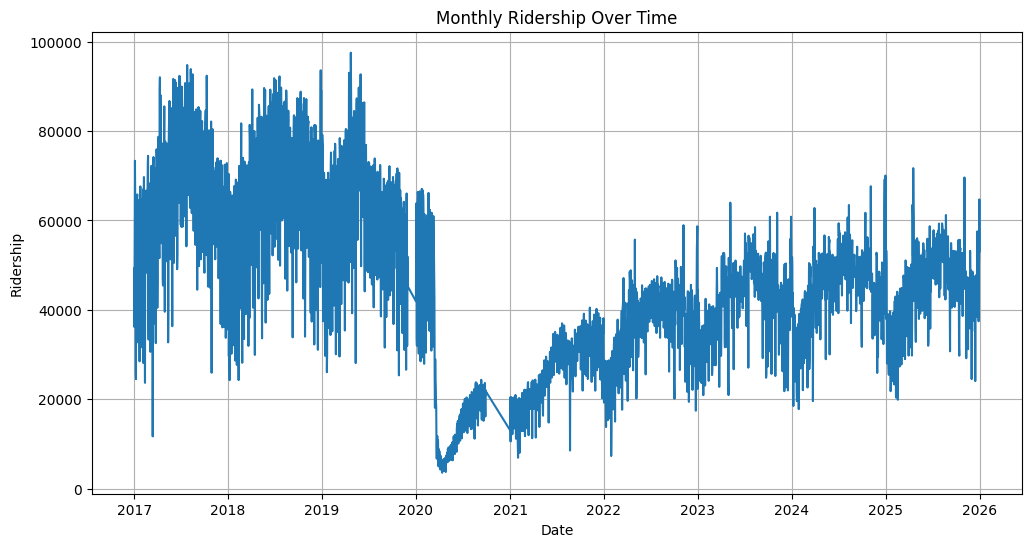

In [ ]:
import matplotlib.pyplot as plt

# Ensure sorted by date
combined_df = combined_df.sort_values('Date')

# Aggregate daily totals
daily_ridership = combined_df.groupby('Date')['Combined'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_ridership)
plt.title('Monthly Ridership Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.grid()
plt.show()

Plotting the rolling average. Good way to see long-term trends.

In [ ]:
window_size = 30

rolling_avg = daily_ridership.rolling(window=window_size).mean()

# Convert to DataFrame so we can work with dates
rolling_df = rolling_avg.reset_index()
rolling_df.columns = ['Date', 'rolling_avg']

# OPTIONAL: remove early NaN values from rolling window
rolling_df = rolling_df.dropna(subset=['rolling_avg'])

# Add month (year + month to avoid mixing years)
rolling_df['year_month'] = rolling_df['Date'].dt.to_period('M')

# Compute monthly average of rolling values
monthly_rolling_avg = (
    rolling_df.groupby('year_month')['rolling_avg']
    .mean()
    .reset_index(name='avg_rolling_ridership')
)

# Convert to integers (round first!)
monthly_rolling_avg['avg_rolling_ridership'] = (
    monthly_rolling_avg['avg_rolling_ridership']
    .round(0)
    .astype('Int64')  # handles missing values safely
)

# Optional: make month labels cleaner for display/plotting
monthly_rolling_avg['year_month'] = monthly_rolling_avg['year_month'].astype(str)

# Print results
print(f"Rolling average window size: {window_size}")
print(monthly_rolling_avg)

Plotting rolling average

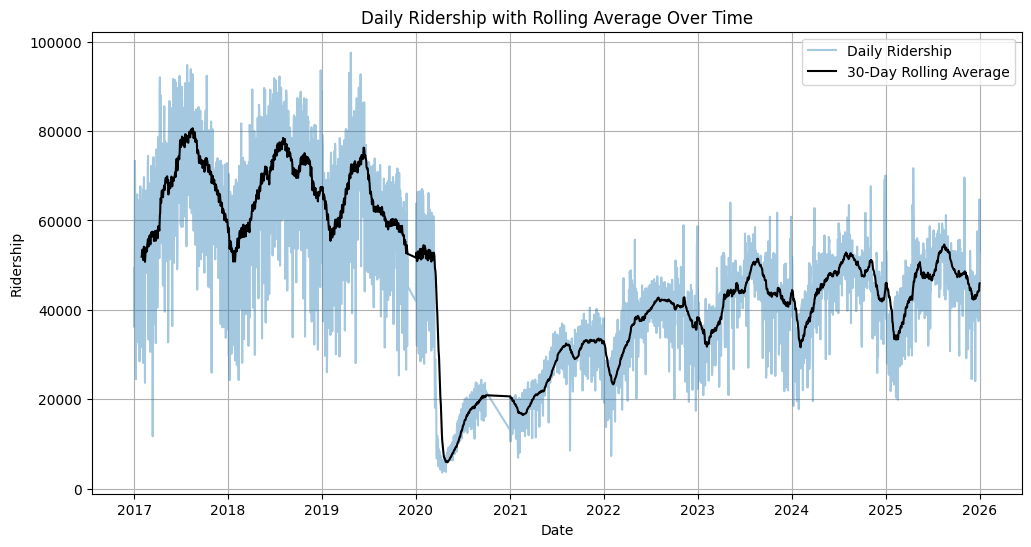

In [ ]:
import matplotlib.pyplot as plt

# The daily_ridership and combined_df are already prepared from previous cells.
# window_size is also defined in a previous cell, but re-defining for clarity in this plot cell.
window_size = 30

# Calculate the rolling average
rolling_avg = daily_ridership.rolling(window=window_size).mean()

# Plotting the daily ridership and the rolling average
plt.figure(figsize=(12,6))
plt.plot(daily_ridership, alpha=0.4, label='Daily Ridership')
plt.plot(rolling_avg, color='black', label=f'{window_size}-Day Rolling Average')
plt.title('Daily Ridership with Rolling Average Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

Peak Travel Days (Day of Week)

weekday
Monday       49383
Tuesday      56125
Wednesday    51219
Thursday     51275
Friday       51750
Saturday     40986
Sunday       35366
Name: Combined, dtype: int64


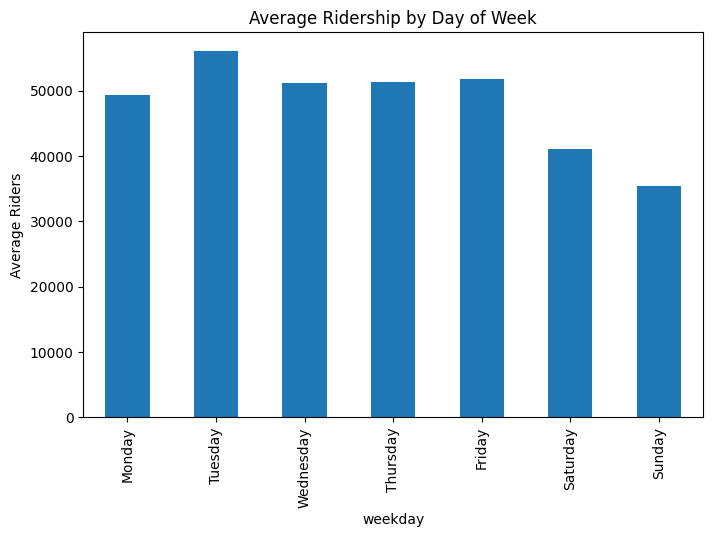

In [ ]:
# Create weekday column
combined_df['weekday'] = combined_df['Date'].dt.day_name()

# Define the chronological order for weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert the 'weekday' column to a Categorical type with the specified order
combined_df['weekday'] = pd.Categorical(combined_df['weekday'], categories=weekday_order, ordered=True)

Ridership = combined_df.groupby('weekday', observed=False)['Combined'].mean().round(0).astype(int)

print(Ridership)

Ridership.plot(kind='bar', figsize=(8,5))
plt.title('Average Ridership by Day of Week')
plt.ylabel('Average Riders')
plt.show()

Peak Travel Months

month_name
January      40587
February     42835
March        43673
April        45587
May          48103
June         49909
July         52241
August       51718
September    48441
October      53110
November     48982
December     47322
Name: Combined, dtype: int64


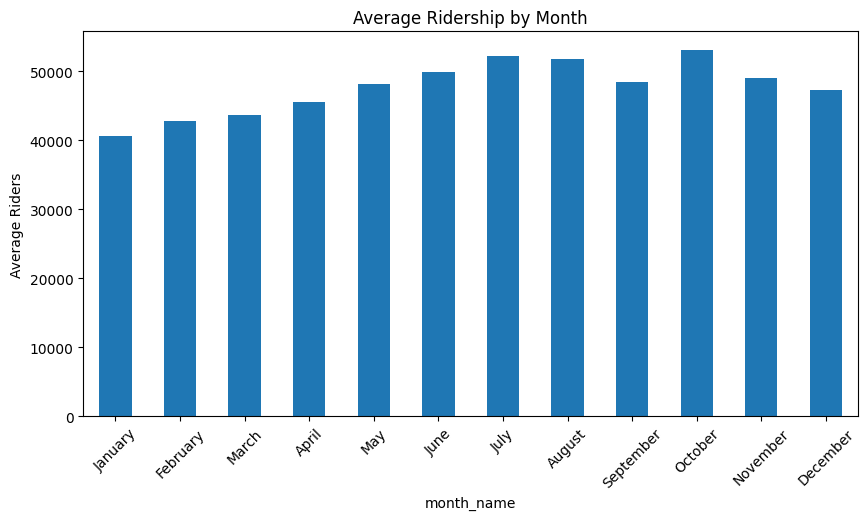

In [ ]:
combined_df['month'] = combined_df['Date'].dt.month
combined_df['month_name'] = combined_df['Date'].dt.month_name()

monthly_avg = combined_df.groupby('month_name')['Combined'].mean()

# Optional: reorder months properly
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_avg = monthly_avg.reindex(month_order)

print(monthly_avg.round(0).astype(int))

monthly_avg.plot(kind='bar', figsize=(10,5))
plt.title('Average Ridership by Month')
plt.ylabel('Average Riders')
plt.xticks(rotation=45)
plt.show()

Comparing Pre/Post COVID Ridership

In [ ]:
covid_start = '2020-03-01'

pre_covid = combined_df[combined_df['Date'] < covid_start]
post_covid = combined_df[combined_df['Date'] >= covid_start]

print("Pre-COVID avg:", pre_covid['Combined'].mean().round(0).astype(int))
print("Post-COVID avg:", post_covid['Combined'].mean().round(0).astype(int))

Pre-COVID avg: 65156
Post-COVID avg: 37216


Plotting on a Bar Chart

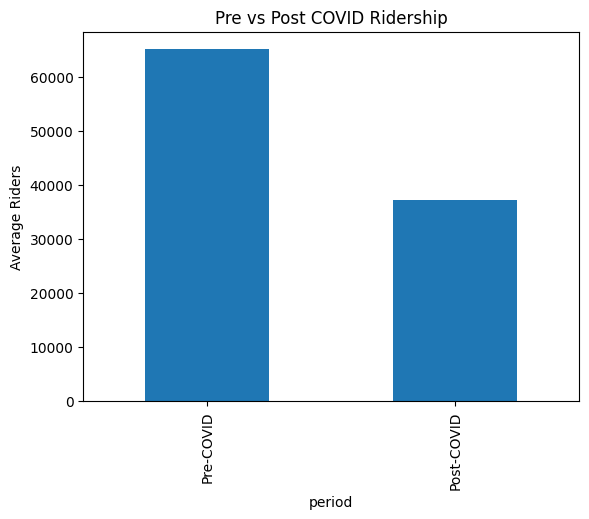

In [ ]:
combined_df['period'] = combined_df['Date'].apply(
    lambda x: 'Pre-COVID' if x < pd.to_datetime(covid_start) else 'Post-COVID'
)

# Define the chronological order for the 'period' column
period_order = ['Pre-COVID', 'Post-COVID']

# Convert the 'period' column to a categorical type with the specified order
combined_df['period'] = pd.Categorical(combined_df['period'], categories=period_order, ordered=True)

combined_df.groupby('period', observed=False)['Combined'].mean().plot(kind='bar')
plt.title('Pre vs Post COVID Ridership')
plt.ylabel('Average Riders')
plt.show()

Comparing Presidents (Trump vs Biden vs Trump again)

In [ ]:
#Defining time periods by presidential terms
def label_president(date):
    if pd.to_datetime('2017-01-20') <= date <= pd.to_datetime('2021-01-20'):
        return 'Trump (1st Term)'
    elif pd.to_datetime('2021-01-20') < date <= pd.to_datetime('2025-01-20'):
        return 'Biden'
    elif date > pd.to_datetime('2025-01-20'):
        return 'Trump (2nd Term)'
    else:
        return 'Pre-Trump'

combined_df['president'] = combined_df['Date'].apply(label_president)

Plotting ridership by presidential term

president
Pre-Trump           52318
Trump (1st Term)    56958
Biden               38529
Trump (2nd Term)    46192
Name: Combined, dtype: int64


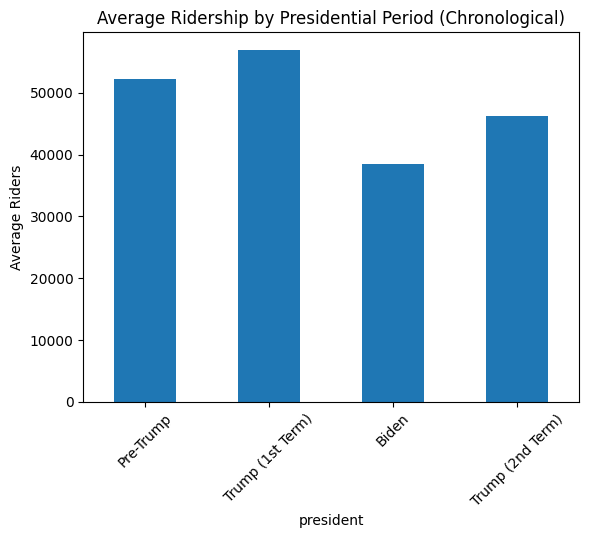

In [ ]:
pres_summary = combined_df.groupby('president')['Combined'].mean()

# Define the chronological order for presidential terms
chronological_order = ['Pre-Trump', 'Trump (1st Term)', 'Biden', 'Trump (2nd Term)']

# Reindex the pres_summary Series to reflect the chronological order
pres_summary_ordered = pres_summary.reindex(chronological_order)

print(pres_summary_ordered.round(0).astype(int))

pres_summary_ordered.plot(kind='bar')
plt.title('Average Ridership by Presidential Period (Chronological)')
plt.ylabel('Average Riders')
plt.xticks(rotation=45) # Rotate labels for better readability if needed
plt.show()

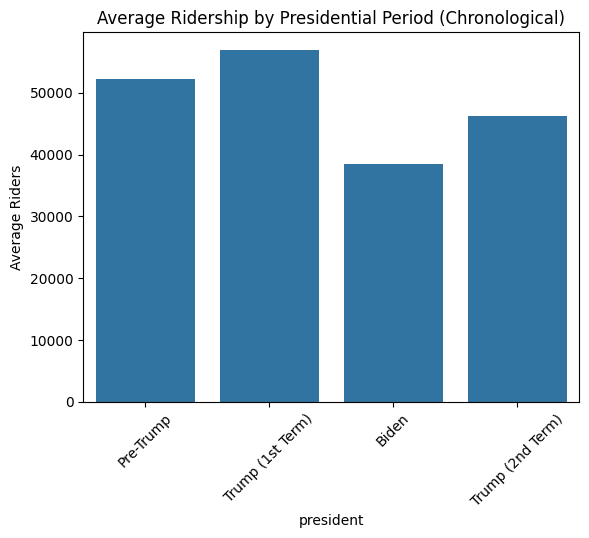

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate pres_summary, round it to 0 decimal places, and convert to integer
pres_summary_rounded = combined_df.groupby('president')['Combined'].mean().round(0).astype(int)

# Define the chronological order for presidential terms
chronological_order = ['Pre-Trump', 'Trump (1st Term)', 'Biden', 'Trump (2nd Term)']

# Reindex the pres_summary_rounded Series to reflect the chronological order
pres_summary_rounded_ordered = pres_summary_rounded.reindex(chronological_order)

sns.barplot(
    x=pres_summary_rounded_ordered.index, # Use the president names as x-axis labels
    y=pres_summary_rounded_ordered.values # Use the rounded average ridership as y-axis values
)

plt.title('Average Ridership by Presidential Period (Chronological)')
plt.ylabel('Average Riders') # Re-adding ylabel for clarity
plt.xticks(rotation=45)
plt.show()